In [1]:
import pandas as pd
import sys
import os

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [2]:
file_path = r"..\data\processed\corpus_date_formatted.xlsx"
corpus = pd.read_excel(file_path, engine='openpyxl')

In [6]:
# Aplicar limpieza al corpus
corpus = utils.aplicar_funcion_limpieza(corpus)

path_processed = r"..\data\processed"

corpus.to_excel(os.path.join(path_processed, 'corpus_cleaned.xlsx'), index=False)


In [ ]:
# Crear chunks solapados
chunks_df = utils.crear_chunks(corpus, columna_texto='Texto_limpio', tamaño=300, solapamiento=50, umbral_minimo=100)

# Ver primeros resultados
print(chunks_df.head())


   id_doc                 autor_doc  fecha_doc     diario_doc  \
0       1         Gonzalo Hernández 2018-01-01  El Espectador   
1       1         Gonzalo Hernández 2018-01-01  El Espectador   
2       2  Eduardo Barajas Sandoval 2018-01-01  El Espectador   
3       2  Eduardo Barajas Sandoval 2018-01-01  El Espectador   
4       2  Eduardo Barajas Sandoval 2018-01-01  El Espectador   

                 titulo_doc  chunk_id  \
0  Fajardo: para nada tibio         0   
1  Fajardo: para nada tibio         1   
2        Macedonia de Norte         0   
3        Macedonia de Norte         1   
4        Macedonia de Norte         2   

                                         texto_chunk  
0  La Coalición Colombia Partido Alianza Verde, P...  
1  posible costo electoral que pocos asumen. Mani...  
2  Las interpretaciones de la historia sirven com...  
3  y culturales, y del poder político: la hoy Mac...  
4  Olimpo. En gracia de discusión, y solamente co...  


In [7]:
cols_str = ["titulo_doc", "autor_doc", "diario_doc"]
chunks_df[cols_str] = chunks_df[cols_str].astype(str)

In [11]:
len(corpus['Texto_limpio'][0].split())

534

In [7]:
# Exportar chunks a Excel 
chunks_excel_path = r"..\data\processed\chunks.xlsx"
chunks_df.to_excel(chunks_excel_path, index=False, engine="openpyxl")

chunks_parquet_path = r"..\data\processed\chunks.parquet"
chunks_df.to_parquet(chunks_parquet_path, index=False, engine="pyarrow")

print("Chunks exportados a Excel y Parquet.")


Chunks exportados a Excel y Parquet.


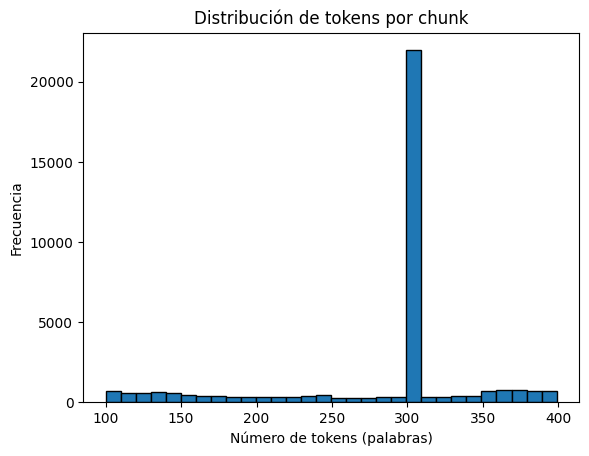

In [12]:
# Contar tokens como número de palabras
tokens_por_chunk = chunks_df["texto_chunk"].apply(lambda x: len(x.split()))

# Graficar histograma
import matplotlib.pyplot as plt

plt.hist(tokens_por_chunk, bins=30, edgecolor="black")
plt.xlabel("Número de tokens (palabras)")
plt.ylabel("Frecuencia")
plt.title("Distribución de tokens por chunk")
plt.show()


In [13]:
tokens_por_chunk.describe()

count    35319.000000
mean       281.894589
std         65.064484
min        100.000000
25%        300.000000
50%        300.000000
75%        300.000000
max        399.000000
Name: texto_chunk, dtype: float64